# Little example on how the supernet works

In [ ]:
import sys
import os
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


from ws_universale.nb201 import sample_nb201_networks
from ws_universale.supernet import Supernet

networks = sample_nb201_networks(N=1)

supernet = Supernet()
supernet.build(networks)
print(supernet)

supernet.summary()


Supernet(1 subnet note, 6 archi, 6 op totali)
Supernet(1 subnet note, 6 archi, 6 op totali)
  SuperEdge('0'→'1', MixedOp(['skip_connect']))
  SuperEdge('0'→'2', MixedOp(['skip_connect']))
  SuperEdge('1'→'2', MixedOp(['skip_connect']))
  SuperEdge('0'→'3', MixedOp(['nor_conv_1x1']))
  SuperEdge('1'→'3', MixedOp(['nor_conv_3x3']))
  SuperEdge('2'→'3', MixedOp(['nor_conv_3x3']))


watch as the supernet increase its size as new network are fed in

In [2]:
networks = sample_nb201_networks(N=1)
supernet.expand(networks)

supernet.summary()

Supernet(2 subnet note, 6 archi, 12 op totali)
  SuperEdge('0'→'1', MixedOp(['skip_connect', 'none']))
  SuperEdge('0'→'2', MixedOp(['skip_connect', 'avg_pool3x3']))
  SuperEdge('1'→'2', MixedOp(['skip_connect', 'nor_conv_1x1']))
  SuperEdge('0'→'3', MixedOp(['nor_conv_1x1', 'none']))
  SuperEdge('1'→'3', MixedOp(['nor_conv_3x3', 'nor_conv_1x1']))
  SuperEdge('2'→'3', MixedOp(['nor_conv_3x3', 'avg_pool3x3']))


In [3]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from utils_functions.utils import get_cifar10_loaders, get_cifar100_loaders

train_loader, val_loader = get_cifar100_loaders(batch_size=256)

tensorflow is not installed.


this might take a while (approximatly 1 hour) but see how the supernet converges

In [4]:
import torch.nn as nn
import torch

supernet = Supernet()

population = sample_nb201_networks(N=256, seed=42)

accuracies = supernet.eval_subnets(
    networks      = population,
    train_loader  = train_loader,
    eval_loader   = val_loader,
    device        = "cuda",
    bn_batches    = 1024,
    epochs        = 120,
    calibrate     = True,
    M             = 1,
    criterion     = nn.CrossEntropyLoss(label_smoothing=0.1),
    use_label_smoothing = True,
    scheduler_factory   = lambda opt: torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=200, eta_min=1e-4
    ),
    n_classes     = 100,
    optimizer_factory   = lambda p: torch.optim.SGD(
        p, lr=0.025, momentum=0.9, weight_decay=3e-4, nesterov=True
    ),
)

Epoch   0 | Batch    0 | Loss: 4.6196 | LR: 0.025000 | Path noti: 254
Epoch   0 | Batch   25 | Loss: 4.6571 | LR: 0.025000 | Path noti: 254
Epoch   0 | Batch   50 | Loss: 4.6335 | LR: 0.025000 | Path noti: 254
Epoch   0 | Batch   75 | Loss: 4.5846 | LR: 0.025000 | Path noti: 254
Epoch   0 | Batch  100 | Loss: 4.5204 | LR: 0.025000 | Path noti: 254
Epoch   0 | Batch  125 | Loss: 4.5562 | LR: 0.025000 | Path noti: 254
Epoch   0 | Batch  150 | Loss: 4.5948 | LR: 0.025000 | Path noti: 254
Epoch   0 | Batch  175 | Loss: 4.3939 | LR: 0.025000 | Path noti: 254
Epoch   1 | Batch    0 | Loss: 4.3230 | LR: 0.024998 | Path noti: 254
Epoch   1 | Batch   25 | Loss: 4.4461 | LR: 0.024998 | Path noti: 254
Epoch   1 | Batch   50 | Loss: 4.4496 | LR: 0.024998 | Path noti: 254
Epoch   1 | Batch   75 | Loss: 4.4248 | LR: 0.024998 | Path noti: 254
Epoch   1 | Batch  100 | Loss: 4.3758 | LR: 0.024998 | Path noti: 254
Epoch   1 | Batch  125 | Loss: 4.2763 | LR: 0.024998 | Path noti: 254
Epoch   1 | Batch  1

In [ ]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from nats_bench import create
from ws_universale.nb201 import networkdag_to_nb201_str
from dataset_loader import load_nas201_api, fetch_gt_accuracies
from utils_functions.plots_utils import compute_and_plot_correlation


BASE_DIR    = os.getcwd()
DATASET_DIR = "Deep-Learning-Project/datasets"


ImportError: cannot import name 'compute_and_plot_correlation' from 'utils_functions.plots_utils' (c:\Users\aless\Desktop\Deep Lerning\progetto\flownas\Deep-Learning-Project\utils_functions\plots_utils.py)

Dataset NAS201 già estratto.
Architetture NAS201 totali: 15625
Architetture trovate nel benchmark: 256/256
                                                                                            arch_str  Accuracy  GT_Accuracy
0                    |none~0|+|none~0|nor_conv_1x1~1|+|skip_connect~0|skip_connect~1|skip_connect~2|     14.25    57.866667
1                            |none~0|+|avg_pool_3x3~0|none~1|+|avg_pool_3x3~0|nor_conv_3x3~1|none~2|     12.99    46.913333
2                    |none~0|+|none~0|skip_connect~1|+|skip_connect~0|avg_pool_3x3~1|avg_pool_3x3~2|     13.82    57.720000
3            |none~0|+|avg_pool_3x3~0|skip_connect~1|+|avg_pool_3x3~0|nor_conv_3x3~1|skip_connect~2|     13.46    44.780000
4            |nor_conv_3x3~0|+|avg_pool_3x3~0|nor_conv_1x1~1|+|none~0|skip_connect~1|nor_conv_3x3~2|     16.78    68.913333
5            |nor_conv_1x1~0|+|nor_conv_1x1~0|skip_connect~1|+|skip_connect~0|nor_conv_1x1~1|none~2|     16.08    66.793333
6                    |non

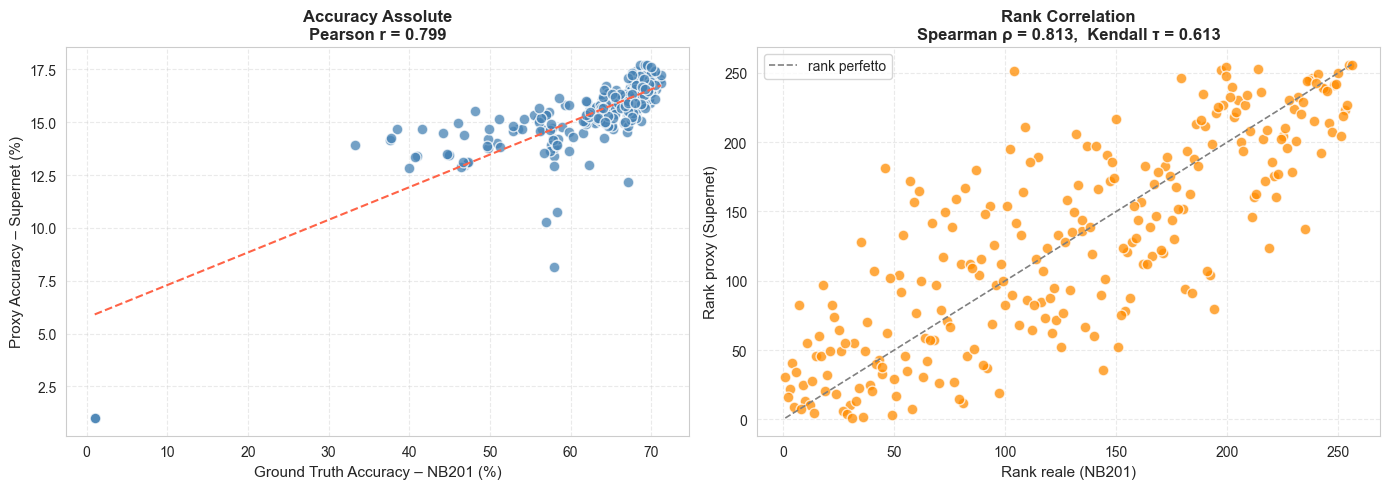

In [11]:
# ── cella 2: confronto con ground truth ───────────────────────────────────────

df_results = fetch_gt_accuracies(
    networks   = population,    # list[NetworkDAG] dalla cella 1
    accuracies = accuracies,    # list[float] dalla supernet
    dataset    = 'cifar100',
    hp         = '200',
)

print(df_results[['arch_str','Accuracy','GT_Accuracy']].to_string())

correlations = compute_and_plot_correlation(df_results)

In [ ]:
# df_results.to_csv('risultati_accuracies.csv', index=False)